In [30]:
#  Imports & Setup

# Core Graph Components
from langgraph.graph import StateGraph, START, END

# LLM
from langchain_openai import ChatOpenAI

# Typing
from typing import TypedDict, Annotated

# Messages
from langchain_core.messages import BaseMessage, HumanMessage

# Reducer
from langgraph.graph.message import add_messages

# Persistence
from langgraph.checkpoint.memory import MemorySaver

# Env
from dotenv import load_dotenv
load_dotenv()

True

### 💬 4. Message Types (Important for Interviews)

LangChain defines structured message types:

* **HumanMessage** → User input
* **AIMessage** → Model response
* **SystemMessage** → Instructions/behavior
* **ToolMessage** → Tool outputs

👉 All inherit from `BaseMessage`

In [32]:
# State Design (VERY IMPORTANT)

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

### Why this matters:

* `messages` → Stores conversation history
* `add_messages` → Acts as a **reducer**

👉 Without reducer:

* New messages overwrite old ones ❌

👉 With reducer:

* Messages are appended ✅ (like chat memory)

In [33]:
#LLM Initialization

llm = ChatOpenAI(model="gpt-4o")

In [34]:
# Core Chat Node

def chat_node(state: ChatState):
    """
    This node:
    1. Reads conversation history
    2. Sends it to LLM
    3. Returns new response
    """

    messages = state["messages"]

    response = llm.invoke(messages)

    return {
        "messages": [response]  # Must return list for reducer
    }

In [35]:
# Build Graph

graph = StateGraph(ChatState)

# Add node
graph.add_node("chat_node", chat_node)

# Define flow
graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

In [36]:
# Compile Graph

chatbot = graph.compile()

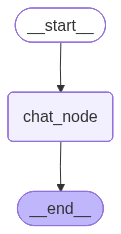

In [37]:
chatbot

In [38]:
# Single Query Test

initial_state = {
    "messages": [HumanMessage(content="What is the capital of India?")]
}

response = chatbot.invoke(initial_state)

print(response["messages"][-1].content)

The capital of India is New Delhi.


In [39]:
chatbot.invoke(initial_state)

{'messages': [HumanMessage(content='What is the capital of India?', additional_kwargs={}, response_metadata={}, id='c3cf0eea-467d-4889-90aa-f630a218cbba'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 14, 'total_tokens': 22, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_2ca5b70601', 'id': 'chatcmpl-DThuHiQyZ6ikf9H25I4ZUcVLGOqXX', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--cd5e376b-dc30-4d22-82d9-b8e872ac315b-0', usage_metadata={'input_tokens': 14, 'output_tokens': 8, 'total_tokens': 22, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [40]:
chatbot.invoke(initial_state)['messages'][1].content

'The capital of India is New Delhi.'

In [41]:
# Interactive Chat Loop (Stateless)

while True:
    user_input = input("User: ")

    if user_input.lower() in ["exit", "quit", "bye"]:
        break

    response = chatbot.invoke({
        "messages": [HumanMessage(content=user_input)]
    })

    print("AI:", response["messages"][-1].content)

AI: Hello Akash! How can I assist you today?
AI: I'm sorry, but I don't have access to personal data about individuals unless it has been shared with me in the course of our conversation. Therefore, I don't know your name. If you'd like, you can tell me your name or any other information you wish to share.


- Adding Memory (Persistence)
#### Problem:
    - Stateless chatbot → forgets history every turn

#### Solution:
    - Use **Checkpointer**
    - checkpointer = MemorySaver()

In [42]:
checkpointer = MemorySaver()

In [43]:
#  Graph with Memory

graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)

graph.add_edge(START, "chat_node")
graph.add_edge("chat_node", END)

chatbot = graph.compile(checkpointer=checkpointer)

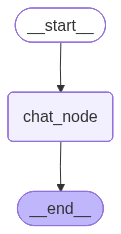

In [44]:
chatbot

In [45]:
# Thread-based Conversation

thread_id = "user_1"

In [46]:
# Each thread = separate conversation

# Stateful Chat Loop

while True:
    user_input = input("User: ")

    if user_input.lower() in ["exit", "quit", "bye"]:
        break

    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    response = chatbot.invoke(
        {"messages": [HumanMessage(content=user_input)]},
        config=config
    )

    print("AI:", response["messages"][-1].content)

AI: Hello, Akash! How can I assist you today?
AI: Your name is Akash. How can I help you today?
AI: 10 plus 100 equals 110.
AI: Multiplying 110 by 2 gives you 220.


In [47]:
# Inspect State

chatbot.get_state(config=config)

# Useful for:

# * Debugging
# * Observability
# * Interview explanation

StateSnapshot(values={'messages': [HumanMessage(content='Hi, my Name is Akash', additional_kwargs={}, response_metadata={}, id='c4bbe8d5-d236-434e-955b-bcb7e025512a'), AIMessage(content='Hello, Akash! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 14, 'total_tokens': 26, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_7a9ae34122', 'id': 'chatcmpl-DThvblsYPh3ITJXOpXipbKf7hSnKG', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--bd27a31e-04e8-4498-ba56-1897060dd3da-0', usage_metadata={'input_tokens': 14, 'output_tokens': 12, 'total_tokens': 26, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0

---

# 🧠 17. Architecture Explanation (INTERVIEW GOLD)

**Flow:**

```
User Input → State → Node → LLM → Response → State Update → Output
```

### Components:

* **State** → Stores messages
* **Node** → Executes logic
* **Graph** → Controls flow
* **Reducer** → Maintains history
* **Checkpointer** → Persistence layer

---

# ⚖️ 18. Design Decisions

### ✅ Why reducer?

To prevent state overwrite

### ✅ Why thread_id?

To support multi-user chats

### ✅ Why graph?

To extend into:

* Agents
* Tool calling
* Multi-step workflows

---

# 🚀 19. Possible Improvements (Say this in Interview)

### 🔧 1. Add System Prompt

```python
from langchain_core.messages import SystemMessage

messages = [
    SystemMessage(content="You are a helpful assistant"),
    *state["messages"]
]
```

---

### 🔧 2. Add Streaming

* Real-time responses

---

### 🔧 3. Add Tool Calling

* Calculator
* APIs

---

### 🔧 4. Add RAG (Retrieval)

* Connect to vector DB

---

### 🔧 5. Persistent Storage

Replace MemorySaver with:

* Redis
* Postgres

---

# ⚠️ 20. Common Mistakes (You avoided some 👍)

* ❌ Not using reducer
* ❌ Overwriting state
* ❌ Not using thread_id
* ❌ Treating chatbot as stateless

---

# 🧠 21. How to Explain in Interview (Short Answer)

> “I built a stateful chatbot using LangGraph where I modeled the workflow as a graph. I defined a TypedDict state with a message reducer to maintain chat history. Each user input flows through a node that invokes the LLM, and the output is appended back into state. I also added persistence using a checkpointer with thread-based isolation, which allows multi-session conversations.”

---

# ⭐ Final Feedback (Ruthless Mentor Mode)

What you did well:

* Correct use of `StateGraph`
* Used reducer (big win)
* Implemented persistence (rare for beginners)

What you were missing:

* No architecture explanation
* No design reasoning
* No extensibility thinking
* Weak naming & comments

---

If you want next level 🚀:
I can upgrade this into:

* **Tool-using agent (LangGraph Agent)**
* **RAG chatbot (vector DB + retrieval)**
* **Multi-node workflow (planner + executor)**